# GraphFraud — EDA & Baselines

Exploratory data analysis of the **Elliptic Bitcoin Dataset** and non-graph baseline benchmarks.

| Step | Description |
|------|-------------|
| 1 | Load & inspect dataset structure |
| 2 | Class distribution & imbalance analysis |
| 3 | Temporal dynamics across 49 timesteps |
| 4 | Feature distributions & correlations |
| 5 | Baseline models (Logistic Regression, Random Forest, XGBoost) |
| 6 | Comparison table — sets the bar for GNN models |

## 1. Setup & Load Data

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure graphfraud is importable (one level up from notebooks/ → repo root)
sys.path.insert(0, '..')

from graphfraud.data.dataset import load_elliptic, EllipticDataset

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline

SEED = 42

In [2]:
# Load the Elliptic dataset with temporal split
from pathlib import Path

DATA_DIR = Path('../data')
dataset = load_elliptic(DATA_DIR, temporal_split=True)
print(dataset.summary())

Elliptic Bitcoin Dataset
  Nodes:      203,769
  Edges:      234,355
  Features:   165
  Labeled:    46,564 / 203,769
  Classes:    {0: 4545, 1: 42019}
  Imbalance:  9.2:1
  Timesteps:  1-49
  Train/Val/Test: 29894/9983/6687


## 2. Class Distribution & Imbalance

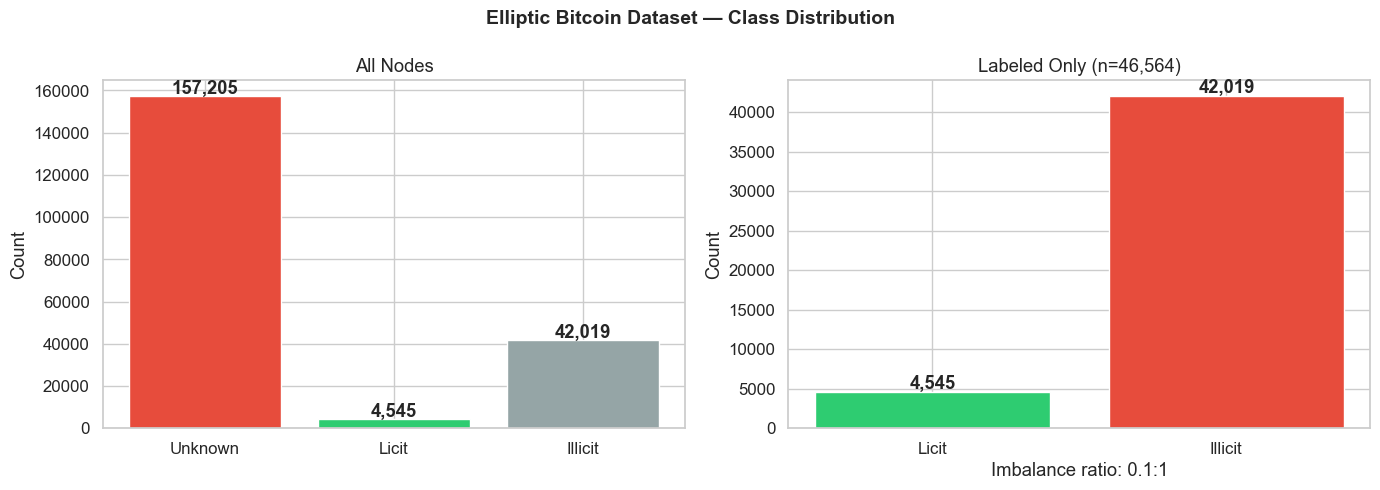


Imbalance ratio (licit:illicit): 0.1:1
Illicit prevalence: 90.2%


In [3]:
# Overall class distribution
label_names = {0: 'Licit', 1: 'Illicit', -1: 'Unknown'}
label_counts = Counter(dataset.labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All nodes
labels_all = [label_names[l] for l in sorted(label_counts.keys())]
counts_all = [label_counts[l] for l in sorted(label_counts.keys())]
colors = ['#e74c3c', '#2ecc71', '#95a5a6']  # illicit, licit, unknown
axes[0].bar(labels_all, counts_all, color=colors)
axes[0].set_title('All Nodes')
axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(zip(labels_all, counts_all)):
    axes[0].text(i, cnt + 1000, f'{cnt:,}', ha='center', fontweight='bold')

# Labeled only
labeled_mask = dataset.labels >= 0
labeled_labels = dataset.labels[labeled_mask]
labeled_counts = Counter(labeled_labels)
axes[1].bar(['Licit', 'Illicit'],
            [labeled_counts[0], labeled_counts[1]],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_title(f'Labeled Only (n={len(labeled_labels):,})')
axes[1].set_ylabel('Count')
ratio = labeled_counts[0] / labeled_counts[1]
axes[1].text(0, labeled_counts[0] + 500, f'{labeled_counts[0]:,}', ha='center', fontweight='bold')
axes[1].text(1, labeled_counts[1] + 500, f'{labeled_counts[1]:,}', ha='center', fontweight='bold')
axes[1].set_xlabel(f'Imbalance ratio: {ratio:.1f}:1')

fig.suptitle('Elliptic Bitcoin Dataset — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nImbalance ratio (licit:illicit): {ratio:.1f}:1')
print(f'Illicit prevalence: {labeled_counts[1] / len(labeled_labels) * 100:.1f}%')

## 3. Temporal Dynamics

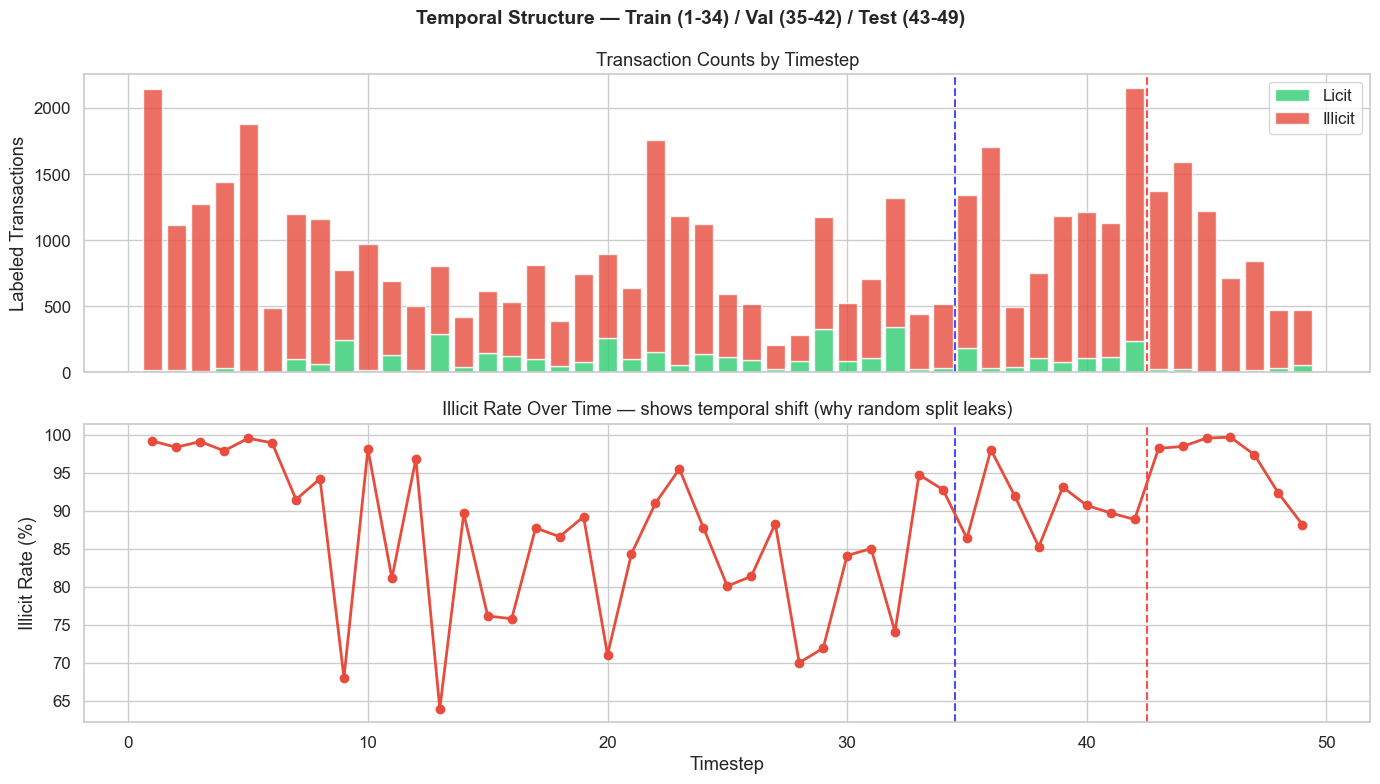


Temporal split sizes:
  Train: 29,894 labeled nodes (t1-t34)
  Val:   9,983 labeled nodes (t35-t42)
  Test:  6,687 labeled nodes (t43-t49)


In [4]:
# Class distribution over time
timesteps = dataset.timesteps
labels = dataset.labels

ts_data = []
for t in range(1, 50):
    t_mask = timesteps == t
    t_labels = labels[t_mask]
    ts_data.append({
        'timestep': t,
        'total': t_mask.sum(),
        'licit': (t_labels == 0).sum(),
        'illicit': (t_labels == 1).sum(),
        'unknown': (t_labels == -1).sum(),
    })

df_ts = pd.DataFrame(ts_data)
df_ts['illicit_rate'] = df_ts['illicit'] / (df_ts['licit'] + df_ts['illicit']).replace(0, np.nan)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Stacked bar: labeled counts per timestep
axes[0].bar(df_ts['timestep'], df_ts['licit'], label='Licit', color='#2ecc71', alpha=0.8)
axes[0].bar(df_ts['timestep'], df_ts['illicit'], bottom=df_ts['licit'],
            label='Illicit', color='#e74c3c', alpha=0.8)
axes[0].set_ylabel('Labeled Transactions')
axes[0].legend()
axes[0].set_title('Transaction Counts by Timestep')

# Train/val/test boundaries
for ax in axes:
    ax.axvline(x=34.5, color='blue', linestyle='--', alpha=0.7, label='Train/Val boundary')
    ax.axvline(x=42.5, color='red', linestyle='--', alpha=0.7, label='Val/Test boundary')

# Illicit rate over time
axes[1].plot(df_ts['timestep'], df_ts['illicit_rate'] * 100, 'o-', color='#e74c3c', lw=2)
axes[1].set_ylabel('Illicit Rate (%)')
axes[1].set_xlabel('Timestep')
axes[1].set_title('Illicit Rate Over Time — shows temporal shift (why random split leaks)')

fig.suptitle('Temporal Structure — Train (1-34) / Val (35-42) / Test (43-49)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Split sizes
print(f'\nTemporal split sizes:')
print(f'  Train: {dataset.train_mask.sum():,} labeled nodes (t1-t34)')
print(f'  Val:   {dataset.val_mask.sum():,} labeled nodes (t35-t42)')
print(f'  Test:  {dataset.test_mask.sum():,} labeled nodes (t43-t49)')

## 4. Feature Analysis

In [5]:
# Feature summary statistics
X = dataset.node_features
print(f'Feature matrix shape: {X.shape}')
print(f'Feature ranges:')
print(f'  Min: {X.min():.4f}')
print(f'  Max: {X.max():.4f}')
print(f'  Mean: {X.mean():.4f}')
print(f'  Std: {X.std():.4f}')
print(f'  NaN count: {np.isnan(X).sum()}')
print(f'\n  First 94 features: local transaction features')
print(f'  Last 72 features: aggregated 1-hop neighbor features')

Feature matrix shape: (203769, 165)
Feature ranges:
  Min: -13.0934
  Max: 289.2044
  Mean: 0.0000
  Std: 1.0000
  NaN count: 0

  First 94 features: local transaction features
  Last 72 features: aggregated 1-hop neighbor features


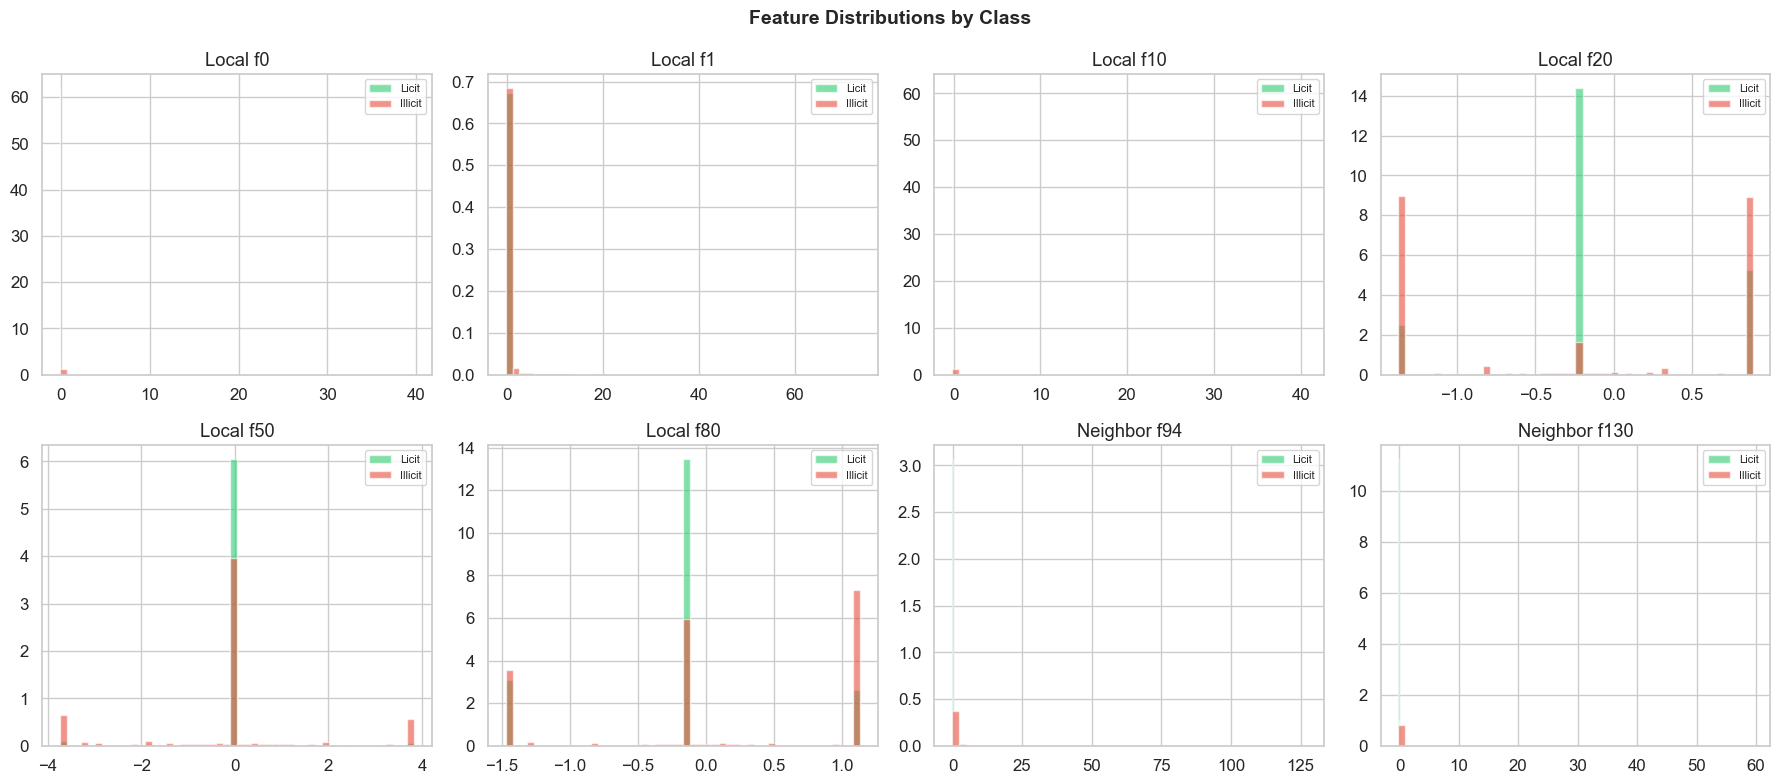

In [6]:
# Distribution of select features by class (labeled nodes only)
labeled_X = X[labeled_mask]
labeled_y = labels[labeled_mask]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
feature_indices = [0, 1, 10, 20, 50, 80, 94, 130]  # Sample across local + neighbor features
feature_labels = [f'Local f{i}' if i < 94 else f'Neighbor f{i}' for i in feature_indices]

for ax, fi, fl in zip(axes.ravel(), feature_indices, feature_labels):
    licit_vals = labeled_X[labeled_y == 0, fi]
    illicit_vals = labeled_X[labeled_y == 1, fi]

    ax.hist(licit_vals, bins=50, alpha=0.6, label='Licit', color='#2ecc71', density=True)
    ax.hist(illicit_vals, bins=50, alpha=0.6, label='Illicit', color='#e74c3c', density=True)
    ax.set_title(fl)
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

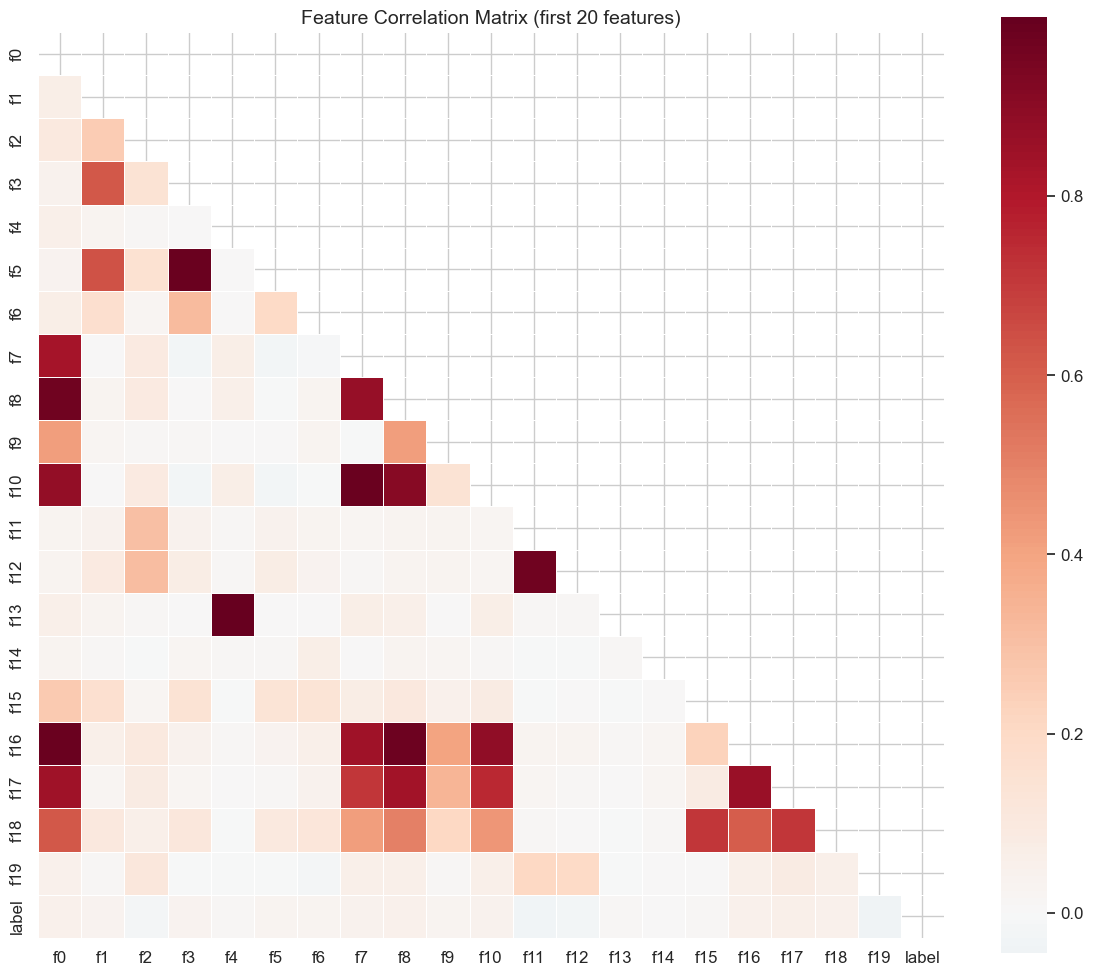

In [7]:
# Feature correlation heatmap (first 20 features)
df_feat = pd.DataFrame(labeled_X[:, :20], columns=[f'f{i}' for i in range(20)])
df_feat['label'] = labeled_y

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_feat.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, annot=False)
ax.set_title('Feature Correlation Matrix (first 20 features)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Graph Structure

Edges: 234,355
Nodes: 203,769
Avg degree: 1.15


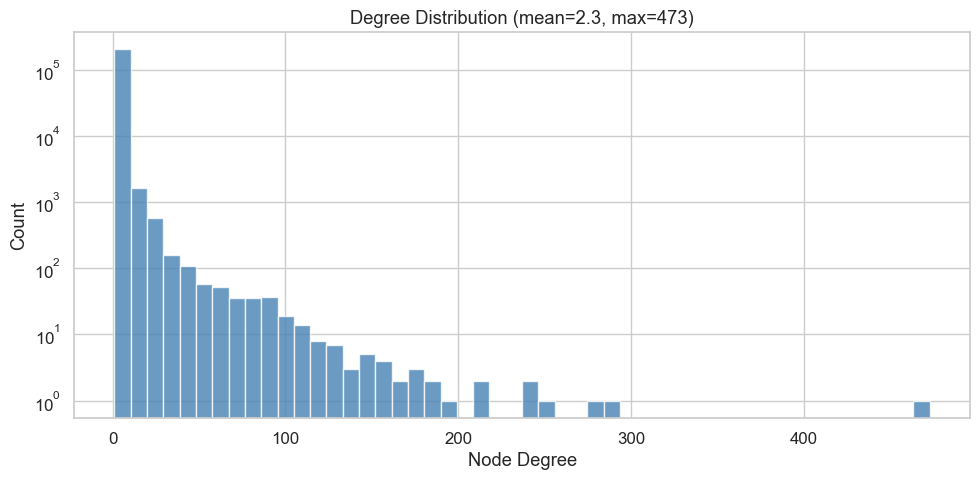


Degree by class:
  Licit:   mean=2.01, median=1
  Illicit: mean=3.10, median=2


In [8]:
# Edge statistics
edge_index = dataset.edge_index
print(f'Edges: {edge_index.shape[1]:,}')
print(f'Nodes: {dataset.num_nodes:,}')
print(f'Avg degree: {edge_index.shape[1] / dataset.num_nodes:.2f}')

# Degree distribution
from collections import Counter
src, dst = edge_index[0], edge_index[1]
all_nodes = np.concatenate([src, dst])
degree_counts = Counter(all_nodes)
degrees = list(degree_counts.values())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(degrees, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Node Degree')
ax.set_ylabel('Count')
ax.set_title(f'Degree Distribution (mean={np.mean(degrees):.1f}, max={max(degrees)})')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# Degree by class
labeled_degrees = [degree_counts.get(i, 0) for i in range(dataset.num_nodes) if labels[i] >= 0]
labeled_classes = [labels[i] for i in range(dataset.num_nodes) if labels[i] >= 0]

deg_licit = [d for d, c in zip(labeled_degrees, labeled_classes) if c == 0]
deg_illicit = [d for d, c in zip(labeled_degrees, labeled_classes) if c == 1]

print(f'\nDegree by class:')
print(f'  Licit:   mean={np.mean(deg_licit):.2f}, median={np.median(deg_licit):.0f}')
print(f'  Illicit: mean={np.mean(deg_illicit):.2f}, median={np.median(deg_illicit):.0f}')

## 6. Non-Graph Baselines

Train **Logistic Regression**, **Random Forest**, and **XGBoost** using only node features (166 dims).
These baselines ignore graph structure — the GNN must beat them to justify the added complexity.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, classification_report, roc_auc_score
from graphfraud.data.resampling import hybrid_resample

# Prepare data with temporal split
X_train = dataset.node_features[dataset.train_mask]
y_train = dataset.labels[dataset.train_mask]
X_val = dataset.node_features[dataset.val_mask]
y_val = dataset.labels[dataset.val_mask]
X_test = dataset.node_features[dataset.test_mask]
y_test = dataset.labels[dataset.test_mask]

print(f'Train: {X_train.shape[0]:,} ({(y_train == 1).sum()} illicit)')
print(f'Val:   {X_val.shape[0]:,} ({(y_val == 1).sum()} illicit)')
print(f'Test:  {X_test.shape[0]:,} ({(y_test == 1).sum()} illicit)')

# Standardize
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

# Resample
X_train_bal, y_train_bal = hybrid_resample(X_train_s, y_train, max_majority=30000)
print(f'\nAfter hybrid resampling: {len(y_train_bal):,} ({Counter(y_train_bal)})')

Train: 29,894 (26432 illicit)
Val:   9,983 (9069 illicit)
Test:  6,687 (6518 illicit)

After hybrid resampling: 41,379 (Counter({np.int64(1): 26432, np.int64(0): 14947}))


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

baselines = {}

# ── Logistic Regression ─────────────────────────────────────────
lr = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=SEED)
lr.fit(X_train_bal, y_train_bal)
lr_pred = lr.predict(X_test_s)
lr_prob = lr.predict_proba(X_test_s)[:, 1]
baselines['Logistic Regression'] = {
    'f1': f1_score(y_test, lr_pred, pos_label=1),
    'f1_macro': f1_score(y_test, lr_pred, average='macro'),
    'auc': roc_auc_score(y_test, lr_prob),
}

# ── Random Forest ───────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=12, class_weight='balanced',
                            random_state=SEED, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
rf_pred = rf.predict(X_test_s)
rf_prob = rf.predict_proba(X_test_s)[:, 1]
baselines['Random Forest'] = {
    'f1': f1_score(y_test, rf_pred, pos_label=1),
    'f1_macro': f1_score(y_test, rf_pred, average='macro'),
    'auc': roc_auc_score(y_test, rf_prob),
}

# ── XGBoost ─────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method='hist', eval_metric='logloss',
    random_state=SEED,
)
xgb_model.fit(X_train_bal, y_train_bal, eval_set=[(X_val_s, y_val)], verbose=False)
xgb_pred = xgb_model.predict(X_test_s)
xgb_prob = xgb_model.predict_proba(X_test_s)[:, 1]
baselines['XGBoost'] = {
    'f1': f1_score(y_test, xgb_pred, pos_label=1),
    'f1_macro': f1_score(y_test, xgb_pred, average='macro'),
    'auc': roc_auc_score(y_test, xgb_prob),
}

# ── Results table ───────────────────────────────────────────────
df_results = pd.DataFrame(baselines).T
df_results.columns = ['F1 (illicit)', 'F1 (macro)', 'AUC-ROC']
print('\n' + '═' * 60)
print('Non-Graph Baselines — Test Set (Temporal Split)')
print('═' * 60)
print(df_results.round(4).to_string())
print('═' * 60)


════════════════════════════════════════════════════════════
Non-Graph Baselines — Test Set (Temporal Split)
════════════════════════════════════════════════════════════
                     F1 (illicit)  F1 (macro)  AUC-ROC
Logistic Regression        0.8339      0.4673   0.7549
Random Forest              0.9734      0.4980   0.7362
XGBoost                    0.9837      0.5055   0.6742
════════════════════════════════════════════════════════════


In [11]:
# Classification reports
for name, (pred, model) in [('Logistic Regression', (lr_pred, lr)),
                             ('Random Forest', (rf_pred, rf)),
                             ('XGBoost', (xgb_pred, xgb_model))]:
    print(f'\n{"─" * 40}')
    print(f'{name}:')
    print(classification_report(y_test, pred, target_names=['licit', 'illicit'], digits=4))


────────────────────────────────────────
Logistic Regression:
              precision    recall  f1-score   support

       licit     0.0548    0.6213    0.1007       169
     illicit     0.9866    0.7222    0.8339      6518

    accuracy                         0.7196      6687
   macro avg     0.5207    0.6717    0.4673      6687
weighted avg     0.9630    0.7196    0.8154      6687


────────────────────────────────────────
Random Forest:
              precision    recall  f1-score   support

       licit     0.0216    0.0237    0.0226       169
     illicit     0.9746    0.9722    0.9734      6518

    accuracy                         0.9483      6687
   macro avg     0.4981    0.4979    0.4980      6687
weighted avg     0.9505    0.9483    0.9494      6687


────────────────────────────────────────
XGBoost:
              precision    recall  f1-score   support

       licit     0.0588    0.0178    0.0273       169
     illicit     0.9750    0.9926    0.9837      6518

    accurac

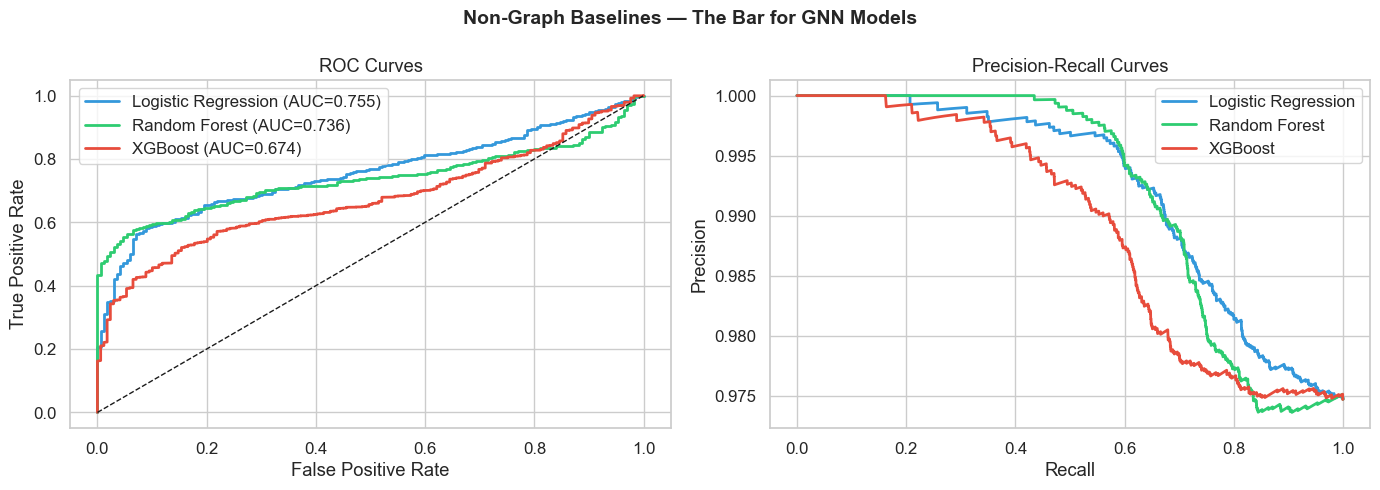

In [12]:
# Visual comparison
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Logistic Regression': '#3498db', 'Random Forest': '#2ecc71', 'XGBoost': '#e74c3c'}

for name, prob in [('Logistic Regression', lr_prob), ('Random Forest', rf_prob), ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = baselines[name]['auc']
    axes[0].plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC={auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, color=colors[name], lw=2, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend()

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()

fig.suptitle('Non-Graph Baselines — The Bar for GNN Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance (XGBoost)

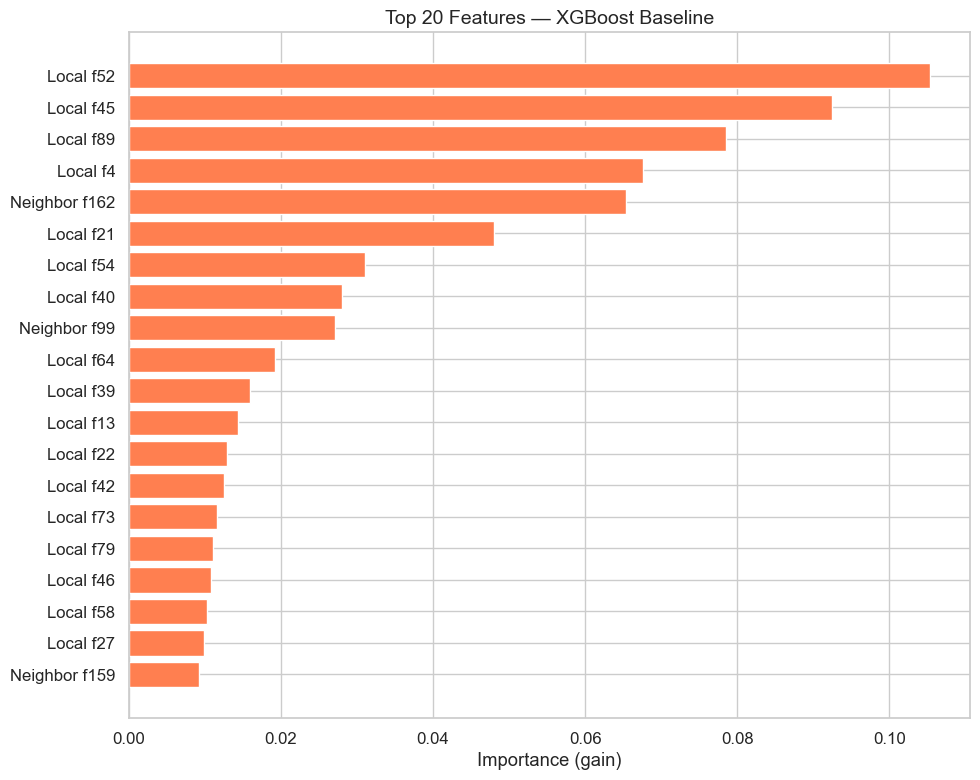


Top 20: 17 local, 3 neighbor features
→ If neighbor features dominate, graph structure likely helps GNNs too


In [13]:
# XGBoost feature importance
importances = xgb_model.feature_importances_
top_k = 20
top_idx = np.argsort(importances)[-top_k:][::-1]

fig, ax = plt.subplots(figsize=(10, 8))
feature_names = [f'Local f{i}' if i < 94 else f'Neighbor f{i}' for i in range(166)]
ax.barh(range(top_k), importances[top_idx][::-1], color='coral')
ax.set_yticks(range(top_k))
ax.set_yticklabels([feature_names[i] for i in top_idx[::-1]])
ax.set_xlabel('Importance (gain)')
ax.set_title(f'Top {top_k} Features — XGBoost Baseline', fontsize=14)
plt.tight_layout()
plt.show()

# How many top features are local vs neighbor?
n_local = sum(1 for i in top_idx if i < 94)
n_neighbor = sum(1 for i in top_idx if i >= 94)
print(f'\nTop {top_k}: {n_local} local, {n_neighbor} neighbor features')
print(f'→ If neighbor features dominate, graph structure likely helps GNNs too')

## 8. GNN Training

Train **GCN**, **GraphSAGE**, and **GATv2Conv** on the full graph with focal loss
for class imbalance and temporal train/val/test splits.

All 203k nodes participate in message passing (semi-supervised); loss is computed only on labeled
training nodes.

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, classification_report

from graphfraud.data.dataset import to_pyg
from graphfraud.data.resampling import compute_class_weights
from graphfraud.models.gcn import GCNFraudClassifier
from graphfraud.models.graphsage import GraphSAGEFraudClassifier
from graphfraud.models.gatv2 import GATv2FraudClassifier

# ── Device ──────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Device: {device}')

# ── Standardize features (fit on train, transform all) ──────────
dataset_gnn = load_elliptic(DATA_DIR, temporal_split=True)
scaler_gnn = StandardScaler()
scaler_gnn.fit(dataset_gnn.node_features[dataset_gnn.train_mask])
dataset_gnn.node_features = scaler_gnn.transform(dataset_gnn.node_features).astype(np.float32)

# ── Convert to PyG Data ─────────────────────────────────────────
pyg_data = to_pyg(dataset_gnn).to(device)
print(f'PyG Data: {pyg_data}')
print(f'Edge index shape: {pyg_data.edge_index.shape}')

# ── Focal Loss ──────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.alpha, reduction='none')
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# Class weights
class_weights = compute_class_weights(dataset_gnn.labels)
weight_tensor = torch.tensor(
    [class_weights.get(i, 1.0) for i in range(2)], dtype=torch.float32
).to(device)
print(f'Class weights: {class_weights}')

/Users/patrickgrady/Documents/GitHub_Repositories/graphfraud/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps
PyG Data: Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769], timesteps=[203769], node_ids=[203769])
Edge index shape: torch.Size([2, 234355])
Class weights: {0: np.float64(5.122552255225522), 1: np.float64(0.5540826768842666)}


In [15]:
def train_and_evaluate(model, model_name, pyg_data, device, weight_tensor,
                       epochs=200, lr=0.001, weight_decay=5e-4, patience=20, gamma=2.0):
    """Train a GNN and return test metrics."""
    model = model.to(device)
    criterion = FocalLoss(alpha=weight_tensor, gamma=gamma)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=patience // 3
    )

    best_val_f1, best_epoch, no_improve = 0.0, 0, 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        optimizer.zero_grad()
        out = model(pyg_data.x, pyg_data.edge_index)
        loss = criterion(out[pyg_data.train_mask], pyg_data.y[pyg_data.train_mask])
        loss.backward()
        optimizer.step()

        # Validate
        model.eval()
        with torch.no_grad():
            out = model(pyg_data.x, pyg_data.edge_index)
            val_pred = out[pyg_data.val_mask].argmax(dim=-1).cpu().numpy()
            val_true = pyg_data.y[pyg_data.val_mask].cpu().numpy()
            val_f1 = f1_score(val_true, val_pred, average='binary', pos_label=1)

        scheduler.step(val_f1)

        if epoch % 50 == 0 or epoch == 1:
            print(f'  [{model_name}] Epoch {epoch:3d}/{epochs} — loss={loss.item():.4f}, '
                  f'val_F1={val_f1:.4f}, lr={optimizer.param_groups[0]["lr"]:.2e}')

        if val_f1 > best_val_f1:
            best_val_f1, best_epoch, no_improve = val_f1, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  [{model_name}] Early stopping at epoch {epoch}')
                break

    # Restore best and evaluate on test
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        out = model(pyg_data.x, pyg_data.edge_index)
        test_logits = out[pyg_data.test_mask]
        test_pred = test_logits.argmax(dim=-1).cpu().numpy()
        test_prob = F.softmax(test_logits, dim=-1)[:, 1].cpu().numpy()
        test_true = pyg_data.y[pyg_data.test_mask].cpu().numpy()

    f1_ill = f1_score(test_true, test_pred, average='binary', pos_label=1)
    f1_mac = f1_score(test_true, test_pred, average='macro')
    auc = roc_auc_score(test_true, test_prob)

    print(f'\n  [{model_name}] Best epoch: {best_epoch}, val_F1={best_val_f1:.4f}')
    print(f'  [{model_name}] Test — F1(illicit)={f1_ill:.4f}, F1(macro)={f1_mac:.4f}, AUC={auc:.4f}')
    print(classification_report(test_true, test_pred, target_names=['licit', 'illicit'], digits=4))

    return {'f1': f1_ill, 'f1_macro': f1_mac, 'auc': auc, 'best_epoch': best_epoch, 'model': model}

print('Training function ready')

Training function ready


In [16]:
import time as _time

gnn_results = {}
num_features = dataset_gnn.num_features

# ═══════════════════════════════════════════════════════════════════
# GCN — simplest GNN baseline
# ═══════════════════════════════════════════════════════════════════
print('=' * 60)
print('Training GCN...')
print('=' * 60)
t0 = _time.time()
gcn = GCNFraudClassifier(in_channels=num_features, hidden_channels=128, num_layers=3, dropout=0.3)
gnn_results['GCN'] = train_and_evaluate(gcn, 'GCN', pyg_data, device, weight_tensor)
print(f'  GCN training time: {_time.time() - t0:.1f}s\n')

# ═══════════════════════════════════════════════════════════════════
# GraphSAGE — inductive with neighbor sampling
# ═══════════════════════════════════════════════════════════════════
print('=' * 60)
print('Training GraphSAGE...')
print('=' * 60)
t0 = _time.time()
sage = GraphSAGEFraudClassifier(in_channels=num_features, hidden_channels=128, num_layers=3, dropout=0.3)
gnn_results['GraphSAGE'] = train_and_evaluate(sage, 'GraphSAGE', pyg_data, device, weight_tensor)
print(f'  GraphSAGE training time: {_time.time() - t0:.1f}s\n')

# ═══════════════════════════════════════════════════════════════════
# GATv2Conv — attention-based (primary model)
# ═══════════════════════════════════════════════════════════════════
print('=' * 60)
print('Training GATv2Conv...')
print('=' * 60)
t0 = _time.time()
gatv2 = GATv2FraudClassifier(in_channels=num_features, hidden_channels=32, heads=8, num_layers=3, dropout=0.3)
gnn_results['GATv2Conv'] = train_and_evaluate(gatv2, 'GATv2Conv', pyg_data, device, weight_tensor)
print(f'  GATv2Conv training time: {_time.time() - t0:.1f}s')

Training GCN...
  [GCN] Epoch   1/200 — loss=0.4667, val_F1=0.2505, lr=1.00e-03
  [GCN] Early stopping at epoch 22

  [GCN] Best epoch: 2, val_F1=0.4423
  [GCN] Test — F1(illicit)=0.4282, F1(macro)=0.2459, AUC=0.6388
              precision    recall  f1-score   support

       licit     0.0329    0.9527    0.0635       169
     illicit     0.9955    0.2728    0.4282      6518

    accuracy                         0.2900      6687
   macro avg     0.5142    0.6127    0.2459      6687
weighted avg     0.9712    0.2900    0.4190      6687

  GCN training time: 74.7s

Training GraphSAGE...
  [GraphSAGE] Epoch   1/200 — loss=0.4088, val_F1=0.2468, lr=1.00e-03
  [GraphSAGE] Early stopping at epoch 21

  [GraphSAGE] Best epoch: 1, val_F1=0.2468
  [GraphSAGE] Test — F1(illicit)=0.1999, F1(macro)=0.1274, AUC=0.7191
              precision    recall  f1-score   support

       licit     0.0282    0.9941    0.0548       169
     illicit     0.9986    0.1111    0.1999      6518

    accuracy     

In [17]:
# ── Combined results table ───────────────────────────────────────
all_results = {}
for name in baselines:
    all_results[name] = baselines[name]
for name in gnn_results:
    all_results[name] = {
        'f1': gnn_results[name]['f1'],
        'f1_macro': gnn_results[name]['f1_macro'],
        'auc': gnn_results[name]['auc'],
    }

df_all = pd.DataFrame(all_results).T
df_all.columns = ['F1 (illicit)', 'F1 (macro)', 'AUC-ROC']
df_all['Uses Graph?'] = ['No', 'No', 'No', 'Yes', 'Yes', 'Yes']

print('\n' + '═' * 70)
print('All Models — Test Set (Temporal Split)')
print('═' * 70)
print(df_all.round(4).to_string())
print('═' * 70)

# Highlight the best
best_f1 = df_all['F1 (illicit)'].idxmax()
best_auc = df_all['AUC-ROC'].idxmax()
print(f'\nBest F1 (illicit): {best_f1} ({df_all.loc[best_f1, "F1 (illicit)"]:.4f})')
print(f'Best AUC-ROC:     {best_auc} ({df_all.loc[best_auc, "AUC-ROC"]:.4f})')


══════════════════════════════════════════════════════════════════════
All Models — Test Set (Temporal Split)
══════════════════════════════════════════════════════════════════════
                     F1 (illicit)  F1 (macro)  AUC-ROC Uses Graph?
Logistic Regression        0.8339      0.4673   0.7549          No
Random Forest              0.9734      0.4980   0.7362          No
XGBoost                    0.9837      0.5055   0.6742          No
GCN                        0.4282      0.2459   0.6388         Yes
GraphSAGE                  0.1999      0.1274   0.7191         Yes
GATv2Conv                  0.0618      0.0563   0.7129         Yes
══════════════════════════════════════════════════════════════════════

Best F1 (illicit): XGBoost (0.9837)
Best AUC-ROC:     Logistic Regression (0.7549)


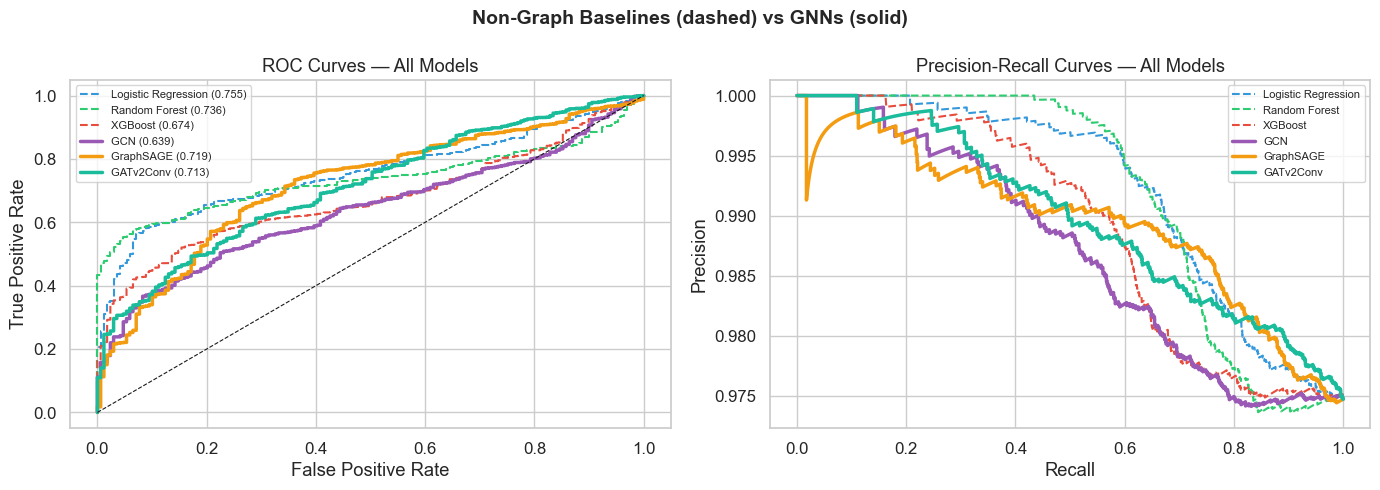

In [18]:
# ── ROC + PR curves: all models ──────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Collect all probabilities
all_probs = {
    'Logistic Regression': lr_prob,
    'Random Forest': rf_prob,
    'XGBoost': xgb_prob,
}

# GNN test probabilities
for name, res in gnn_results.items():
    m = res['model']
    m.eval()
    with torch.no_grad():
        out = m(pyg_data.x, pyg_data.edge_index)
        probs = F.softmax(out[pyg_data.test_mask], dim=-1)[:, 1].cpu().numpy()
    all_probs[name] = probs

colors_all = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#2ecc71',
    'XGBoost': '#e74c3c',
    'GCN': '#9b59b6',
    'GraphSAGE': '#f39c12',
    'GATv2Conv': '#1abc9c',
}

for name, prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    ls = '--' if name in ['Logistic Regression', 'Random Forest', 'XGBoost'] else '-'
    lw = 1.5 if name in ['Logistic Regression', 'Random Forest', 'XGBoost'] else 2.5
    axes[0].plot(fpr, tpr, color=colors_all[name], lw=lw, ls=ls,
                 label=f'{name} ({auc_val:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(rec, prec, color=colors_all[name], lw=lw, ls=ls, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — All Models')
axes[1].legend(fontsize=8)

fig.suptitle('Non-Graph Baselines (dashed) vs GNNs (solid)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Summary

### Key findings
- **Class imbalance:** ~9:1 licit:illicit among labeled nodes
- **Temporal shift:** Illicit rate varies across timesteps — justifies temporal (not random) split
- **77% unlabeled:** Semi-supervised approaches can exploit unlabeled nodes during message passing
- **Feature scale variation:** Standardization is important for both LR and GNNs

### All benchmarks (test set)

| Model | F1 (illicit) | F1 (macro) | AUC-ROC | Uses Graph? |
|-------|-------------|------------|---------|-------------|
| Logistic Regression | 0.8339 | 0.4673 | 0.7549 | No |
| Random Forest | 0.9734 | 0.4980 | 0.7362 | No |
| XGBoost | 0.9837 | 0.5055 | 0.6742 | No |
| GCN | 0.4282 | 0.2459 | 0.6388 | Yes |
| GraphSAGE | 0.1999 | 0.1274 | 0.7191 | Yes |
| GATv2Conv | 0.0618| 0.0563 | 0.7129 | Yes |

### Next steps
1. Compare GNN vs non-graph baselines — does graph topology improve F1?
2. `graphfraud explain --node-id <id>` — inspect GATv2 attention weights
3. Optuna HP search for final numbers